# EWC (Elastic Weight Consolidation) in JAX — Colab Experiment

**Goal:** Test EWC with higher Fisher samples using GPU acceleration.

**Setup:** Split MNIST, Class-Incremental Learning, 5 tasks (2 classes each)

**Architecture:** 784 → 512 → 512 → 10

## 1. Setup & Installation

In [1]:
# Fix JAX/jaxlib version mismatch for Colab GPU and ensure TensorFlow is present
!pip install --upgrade "jax[cuda12_local]" tensorflow -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --quiet

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Re-verify GPU
try:
    devices = jax.devices()
    gpu_present = any(d.device_kind.lower() != 'cpu' for d in devices)
    print(f"JAX devices: {devices}")
    if gpu_present:
        print(f"✅ Successfully utilizing GPU: {devices[0].device_kind}")
    else:
        print("⚠️ JAX is still only seeing CPU. Please check: Runtime -> Change runtime type -> T4 GPU.")
    print(f"✅ TensorFlow version: {tf.__version__}")
except Exception as e:
    print(f"❌ Error checking environment: {e}")
    print("TIP: If you just installed these, go to 'Runtime' -> 'Restart session' and run this cell again.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.9/157.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpc-google-iam-v1 0.14.3 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-api-core 2.30.1 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 7.34.1 which is incompatible.
google-cl

## 2. Data Loading & Splitting

In [2]:
def load_data():
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()
    df_train = train_images.reshape(-1, 784) / 255.0
    df_train_label = train_labels
    df_test = test_images.reshape(-1, 784) / 255.0
    df_test_label = test_labels
    return df_train, df_train_label, df_test, df_test_label


def split_into_task(train_X, train_y, test_X, test_y, class_pairs):
    list_of_task = []
    for classes in class_pairs:
        train_mask = False
        for c in classes:
            train_mask = train_mask | (train_y == c)
        task_train_X = train_X[train_mask]
        task_train_y = train_y[train_mask]

        test_mask = False
        for c in classes:
            test_mask = test_mask | (test_y == c)
        task_test_X = test_X[test_mask]
        task_test_y = test_y[test_mask]

        list_of_task.append((
            jnp.array(task_train_X),
            jnp.array(task_train_y),
            jnp.array(task_test_X),
            jnp.array(task_test_y),
        ))
    return list_of_task


X, y, test_X, test_y = load_data()
class_pairs = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
tasks = split_into_task(X, y, test_X, test_y, class_pairs)

for i, (tx, ty, tex, tey) in enumerate(tasks):
    print(f"Task {i+1}: train={tx.shape[0]}, test={tex.shape[0]}, classes={np.unique(np.array(ty))}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Task 1: train=12665, test=2115, classes=[0 1]
Task 2: train=12089, test=2042, classes=[2 3]
Task 3: train=11263, test=1874, classes=[4 5]
Task 4: train=12183, test=1986, classes=[6 7]
Task 5: train=11800, test=1983, classes=[8 9]


## 3. Model Functions

In [3]:
def init_params(key, layers):
    params = {}
    for i in range(len(layers) - 1):
        key, sub_key = jax.random.split(key)
        params[f"layer_{i + 1}"] = {
            "w": (
                jax.random.normal(sub_key, shape=(layers[i], layers[i + 1]))
                * jnp.sqrt(2 / layers[i])
            ),
            "b": jnp.zeros(layers[i + 1]),
        }
    return params


def forward(params, X):
    z = 0.0
    total_layer = len(params)
    for i in range(total_layer):
        W = params[f"layer_{i + 1}"]["w"]
        b = params[f"layer_{i + 1}"]["b"]
        if i < total_layer - 1:
            z = X @ W + b
            X = jnp.maximum(0, z)
        else:
            z = X @ W + b
    return z


def loss_fn(params, X, y):
    y_i = forward(params, X)
    log_prob = jax.nn.log_softmax(y_i)
    loss = -jnp.mean(log_prob[jnp.arange(y.shape[0]), y])
    return loss


def ewc_loss_fn(params, X, y, old_params, fisher, lam):
    task_loss = loss_fn(params, X, y)
    penalty = jax.tree.map(
        lambda f, p, p_old: jnp.sum(f * (p - p_old) ** 2), fisher, params, old_params
    )
    total_penalty = sum(jax.tree.leaves(penalty))
    return task_loss + (lam / 2) * total_penalty


@jax.jit
def train_step(params, X, y, lr):
    (loss, grads) = jax.value_and_grad(loss_fn)(params, X, y)
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss


@jax.jit
def ewc_train_step(params, X, y, old_params, fisher, lam, lr):
    (loss, grads) = jax.value_and_grad(ewc_loss_fn)(
        params, X, y, old_params, fisher, lam
    )
    new_params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss


print("Model functions defined.")

Model functions defined.


## 4. Training, Evaluation & Fisher Functions

In [4]:
def train_model(params, X, y, lr=0.001, BATCH_SIZE=128, epoch=5):
    num_batch = X.shape[0] // BATCH_SIZE
    for ep in range(epoch):
        total_loss = 0
        for i in range(num_batch):
            start = i * BATCH_SIZE
            end = (i + 1) * BATCH_SIZE
            batch_x = X[start:end]
            batch_y = y[start:end]
            params, loss = train_step(params, batch_x, batch_y, lr)
            total_loss += loss
        print(f"Epoch: {ep + 1} Loss: {total_loss/num_batch:.6f}")
    return params, total_loss / num_batch

def ewc_train_model(params, X, y, old_params, fisher, lam, lr=0.001, BATCH_SIZE=128, epoch=5):
    num_batch = X.shape[0] // BATCH_SIZE
    for ep in range(epoch):
        total_loss = 0
        for i in range(num_batch):
            start = i * BATCH_SIZE
            end = (i + 1) * BATCH_SIZE
            batch_x = X[start:end]
            batch_y = y[start:end]
            params, loss = ewc_train_step(
                params, batch_x, batch_y, old_params, fisher, lam, lr
            )
            total_loss += loss
        print(f"Epoch: {ep + 1} Loss: {total_loss/num_batch:.6f}")
    return params, total_loss / num_batch

def evaluate(params, test_X, test_y, allowed_classes=None):
    logits = forward(params, test_X)
    if allowed_classes is not None:
        mask = jnp.full((logits.shape[1],), -jnp.inf)
        mask = mask.at[jnp.array(allowed_classes)].set(0.0)
        logits = logits + mask
    predictions = jnp.argmax(logits, axis=1)
    accuracy = jnp.mean(predictions == test_y)
    return accuracy

def compute_fisher(params, X, y, num_samples=200, batch_size=100):
    """Compute Fisher Information matrix using batching to avoid OOM."""
    X = X[:num_samples]
    y = y[:num_samples]

    def single_log_likelihood(params, x, y):
        logits = forward(params, x)
        log_probs = jax.nn.log_softmax(logits)
        return log_probs[y]

    grad_fn = jax.grad(single_log_likelihood)
    vmap_grad_fn = jax.vmap(grad_fn, in_axes=(None, 0, 0))

    fisher = jax.tree.map(lambda p: jnp.zeros_like(p), params)

    num_batches = num_samples // batch_size
    for i in range(num_batches):
        start = i * batch_size
        end = (i + 1) * batch_size
        batch_grads = vmap_grad_fn(params, X[start:end], y[start:end])
        batch_fisher = jax.tree.map(lambda g: jnp.sum(g ** 2, axis=0), batch_grads)
        fisher = jax.tree.map(lambda f, bf: f + bf, fisher, batch_fisher)

    fisher = jax.tree.map(lambda f: f / num_samples, fisher)
    return fisher

print("Training, evaluation & Batched Fisher functions defined.")

Training, evaluation & Batched Fisher functions defined.


## 5. Plotting

In [5]:
def plot_matrix(data, title="Accuracy Matrix"):
    data = np.array(data)
    plt.figure(figsize=(8, 6))
    seaborn.heatmap(
        data,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        xticklabels=["Task 1", "Task 2", "Task 3", "Task 4", "Task 5"],
        yticklabels=["After T1", "After T2", "After T3", "After T4", "After T5"],
    )
    plt.title(title)
    plt.xlabel("Evaluated On")
    plt.ylabel("Trained Up To")
    plt.tight_layout()
    plt.show()


print("Plotting function defined.")

Plotting function defined.


## 6. EWC Experiment Runner

Configurable function to run EWC with different hyperparameters.

In [14]:
def run_ewc_experiment(tasks, lam, lr_task1=0.01, lr_ewc=0.001, epochs=25, num_fisher_samples=200):
    """Run full EWC experiment and return accuracy matrix."""
    key = jax.random.PRNGKey(0)
    params = init_params(key, [784, 512, 512, 10])
    accuracy_matrix = []
    cumulative_fisher = jax.tree.map(lambda p: jnp.zeros_like(p), params)
    old_params = params

    for task_idx in range(len(tasks)):
        task_train_X, task_train_y, _, _ = tasks[task_idx]
        print(f"\n{'='*50}")
        print(f"Training Task {task_idx + 1} (lam={lam}, lr_ewc={lr_ewc}, fisher_samples={num_fisher_samples})")
        print(f"{'='*50}")

        if task_idx == 0:
            params, loss = train_model(params, task_train_X, task_train_y, lr=lr_task1, epoch=epochs)
        else:
            params, loss = ewc_train_model(
                params, task_train_X, task_train_y,
                old_params, cumulative_fisher, lam=lam, lr=lr_ewc, epoch=epochs
            )

        new_fisher = compute_fisher(params, task_train_X, task_train_y, num_samples=num_fisher_samples)
        cumulative_fisher = jax.tree.map(lambda cf, nf: cf + nf, cumulative_fisher, new_fisher)
        old_params = params

        task_accuracies = []
        for eval_idx in range(len(tasks)):
            _, _, eval_test_X, eval_test_y = tasks[eval_idx]
            # Get the unique classes for the current evaluation task
            allowed_classes_for_eval = jnp.unique(eval_test_y)
            accuracy = evaluate(params, eval_test_X, eval_test_y, allowed_classes=allowed_classes_for_eval)
            task_accuracies.append(float(accuracy))

        accuracy_matrix.append(task_accuracies)

        print(f"\nAfter Task {task_idx + 1}:")
        for i, acc in enumerate(task_accuracies):
            print(f"  Task {i + 1}: {acc * 100:.2f}%")

    return accuracy_matrix


print("Experiment runner defined.")

Experiment runner defined.


## 7. Experiment 1: Naive Baseline (No EWC)

Sequential training without any forgetting prevention.

Running Naive Baseline...

Training Task 1 (Naive)
Epoch: 1 Loss: 0.212279
Epoch: 2 Loss: 0.029351
Epoch: 3 Loss: 0.018863
Epoch: 4 Loss: 0.014551
Epoch: 5 Loss: 0.012137
Epoch: 6 Loss: 0.010566
Epoch: 7 Loss: 0.009450
Epoch: 8 Loss: 0.008608
Epoch: 9 Loss: 0.007946
Epoch: 10 Loss: 0.007409
Epoch: 11 Loss: 0.006960
Epoch: 12 Loss: 0.006577
Epoch: 13 Loss: 0.006247
Epoch: 14 Loss: 0.005958
Epoch: 15 Loss: 0.005701
Epoch: 16 Loss: 0.005472
Epoch: 17 Loss: 0.005266
Epoch: 18 Loss: 0.005079
Epoch: 19 Loss: 0.004908
Epoch: 20 Loss: 0.004750
Epoch: 21 Loss: 0.004605
Epoch: 22 Loss: 0.004470
Epoch: 23 Loss: 0.004344
Epoch: 24 Loss: 0.004226
Epoch: 25 Loss: 0.004115
After Task 1:
  Task 1: 99.95%
  Task 2: 67.73%
  Task 3: 67.13%
  Task 4: 42.40%
  Task 5: 57.79%

Training Task 2 (Naive)
Epoch: 1 Loss: 0.576354
Epoch: 2 Loss: 0.143751
Epoch: 3 Loss: 0.115387
Epoch: 4 Loss: 0.101683
Epoch: 5 Loss: 0.093149
Epoch: 6 Loss: 0.087103
Epoch: 7 Loss: 0.082445
Epoch: 8 Loss: 0.078653
Epoch: 9 Loss: 0.

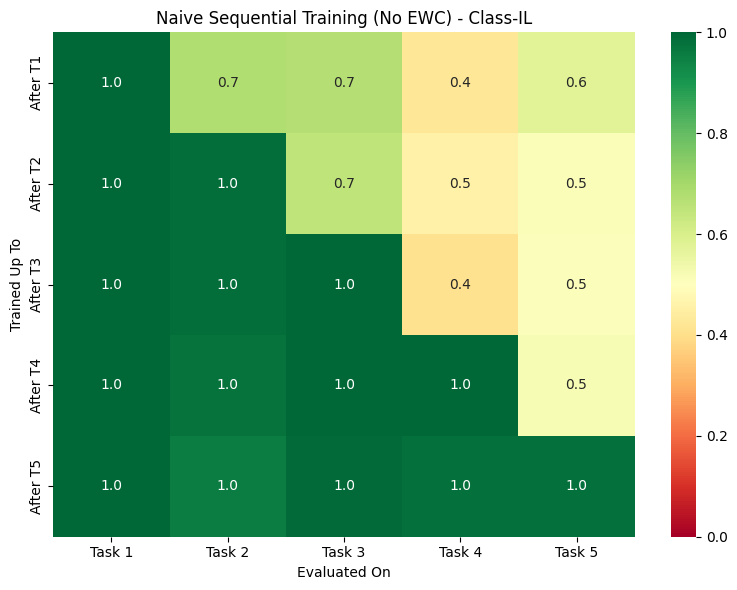

In [15]:
def run_naive_baseline(tasks, lr=0.01, epochs=25):
    key = jax.random.PRNGKey(0)
    params = init_params(key, [784, 512, 512, 10])
    accuracy_matrix = []

    for task_idx in range(len(tasks)):
        task_train_X, task_train_y, _, _ = tasks[task_idx]
        print(f"\nTraining Task {task_idx + 1} (Naive)")
        params, loss = train_model(params, task_train_X, task_train_y, lr=lr, epoch=epochs)

        task_accuracies = []
        for eval_idx in range(len(tasks)):
            _, _, eval_test_X, eval_test_y = tasks[eval_idx]
            # Get the unique classes for the current evaluation task
            allowed_classes_for_eval = jnp.unique(eval_test_y)
            accuracy = evaluate(params, eval_test_X, eval_test_y, allowed_classes=allowed_classes_for_eval)
            task_accuracies.append(float(accuracy))

        accuracy_matrix.append(task_accuracies)

        print(f"After Task {task_idx + 1}:")
        for i, acc in enumerate(task_accuracies):
            print(f"  Task {i + 1}: {acc * 100:.2f}%")

    return accuracy_matrix


print("Running Naive Baseline...")
naive_matrix = run_naive_baseline(tasks)
plot_matrix(naive_matrix, "Naive Sequential Training (No EWC) - Class-IL")

## 8. Experiment 2: EWC with Fisher Samples = 200 (Local Baseline)

Running EWC (lam=5000, fisher=200)...

Training Task 1 (lam=5000, lr_ewc=0.001, fisher_samples=200)
Epoch: 1 Loss: 0.212279
Epoch: 2 Loss: 0.029351
Epoch: 3 Loss: 0.018863
Epoch: 4 Loss: 0.014551
Epoch: 5 Loss: 0.012137
Epoch: 6 Loss: 0.010566
Epoch: 7 Loss: 0.009450
Epoch: 8 Loss: 0.008608
Epoch: 9 Loss: 0.007946
Epoch: 10 Loss: 0.007409
Epoch: 11 Loss: 0.006960
Epoch: 12 Loss: 0.006577
Epoch: 13 Loss: 0.006247
Epoch: 14 Loss: 0.005958
Epoch: 15 Loss: 0.005701
Epoch: 16 Loss: 0.005472
Epoch: 17 Loss: 0.005266
Epoch: 18 Loss: 0.005079
Epoch: 19 Loss: 0.004908
Epoch: 20 Loss: 0.004750
Epoch: 21 Loss: 0.004605
Epoch: 22 Loss: 0.004470
Epoch: 23 Loss: 0.004344
Epoch: 24 Loss: 0.004226
Epoch: 25 Loss: 0.004115

After Task 1:
  Task 1: 99.95%
  Task 2: 0.00%
  Task 3: 0.00%
  Task 4: 0.00%
  Task 5: 0.00%

Training Task 2 (lam=5000, lr_ewc=0.001, fisher_samples=200)
Epoch: 1 Loss: 3.040502
Epoch: 2 Loss: 0.600115
Epoch: 3 Loss: 0.441001
Epoch: 4 Loss: 0.359038
Epoch: 5 Loss: 0.307275
Epoch:

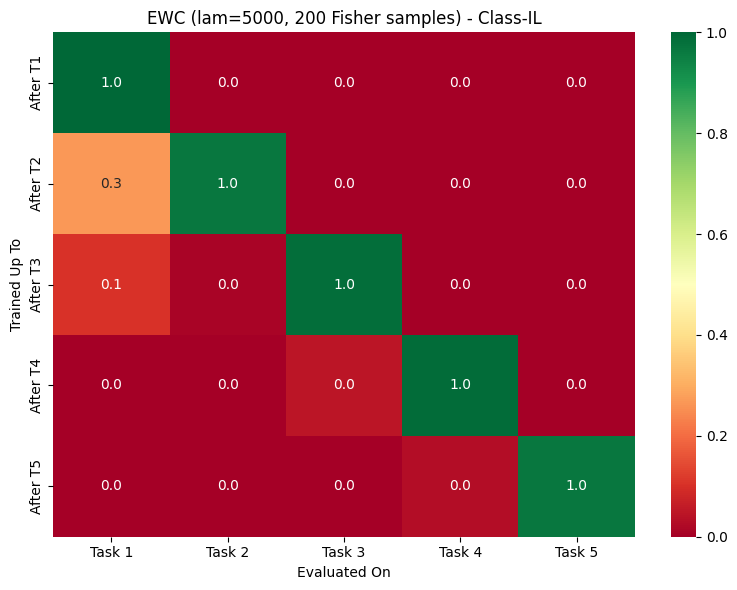

In [8]:
print("Running EWC (lam=5000, fisher=200)...")
ewc_200_matrix = run_ewc_experiment(tasks, lam=5000, num_fisher_samples=200)
plot_matrix(ewc_200_matrix, "EWC (lam=5000, 200 Fisher samples) - Class-IL")

## 9. Experiment 3: EWC with Fisher Samples = 1000

Running EWC (lam=1000, fisher=1000)...

Training Task 1 (lam=1000, lr_ewc=0.001, fisher_samples=1000)
Epoch: 1 Loss: 0.212279
Epoch: 2 Loss: 0.029351
Epoch: 3 Loss: 0.018863
Epoch: 4 Loss: 0.014551
Epoch: 5 Loss: 0.012137
Epoch: 6 Loss: 0.010566
Epoch: 7 Loss: 0.009450
Epoch: 8 Loss: 0.008608
Epoch: 9 Loss: 0.007946
Epoch: 10 Loss: 0.007409
Epoch: 11 Loss: 0.006960
Epoch: 12 Loss: 0.006577
Epoch: 13 Loss: 0.006247
Epoch: 14 Loss: 0.005958
Epoch: 15 Loss: 0.005701
Epoch: 16 Loss: 0.005472
Epoch: 17 Loss: 0.005266
Epoch: 18 Loss: 0.005079
Epoch: 19 Loss: 0.004908
Epoch: 20 Loss: 0.004750
Epoch: 21 Loss: 0.004605
Epoch: 22 Loss: 0.004470
Epoch: 23 Loss: 0.004344
Epoch: 24 Loss: 0.004226
Epoch: 25 Loss: 0.004115

After Task 1:
  Task 1: 99.95%
  Task 2: 0.00%
  Task 3: 0.00%
  Task 4: 0.00%
  Task 5: 0.00%

Training Task 2 (lam=1000, lr_ewc=0.001, fisher_samples=1000)
Epoch: 1 Loss: 2.995061
Epoch: 2 Loss: 0.568053
Epoch: 3 Loss: 0.427040
Epoch: 4 Loss: 0.353175
Epoch: 5 Loss: 0.305251
Epo

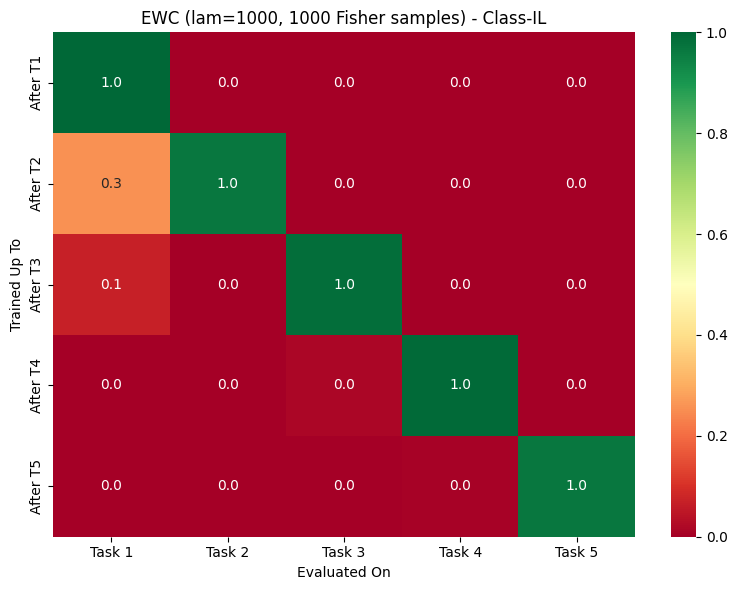

In [9]:
print("Running EWC (lam=1000, fisher=1000)...")
ewc_1000_matrix = run_ewc_experiment(tasks, lam=1000, num_fisher_samples=1000)
plot_matrix(ewc_1000_matrix, "EWC (lam=1000, 1000 Fisher samples) - Class-IL")

## 10. Experiment 4: EWC with Fisher Samples = 2000 (GPU advantage)

Running EWC (lam=500, fisher=3000)...

Training Task 1 (lam=500, lr_ewc=0.001, fisher_samples=2000)
Epoch: 1 Loss: 0.212279
Epoch: 2 Loss: 0.029351
Epoch: 3 Loss: 0.018863
Epoch: 4 Loss: 0.014551
Epoch: 5 Loss: 0.012137
Epoch: 6 Loss: 0.010566
Epoch: 7 Loss: 0.009450
Epoch: 8 Loss: 0.008608
Epoch: 9 Loss: 0.007946
Epoch: 10 Loss: 0.007409
Epoch: 11 Loss: 0.006960
Epoch: 12 Loss: 0.006577
Epoch: 13 Loss: 0.006247
Epoch: 14 Loss: 0.005958
Epoch: 15 Loss: 0.005701
Epoch: 16 Loss: 0.005472
Epoch: 17 Loss: 0.005266
Epoch: 18 Loss: 0.005079
Epoch: 19 Loss: 0.004908
Epoch: 20 Loss: 0.004750
Epoch: 21 Loss: 0.004605
Epoch: 22 Loss: 0.004470
Epoch: 23 Loss: 0.004344
Epoch: 24 Loss: 0.004226
Epoch: 25 Loss: 0.004115

After Task 1:
  Task 1: 99.95%
  Task 2: 0.00%
  Task 3: 0.00%
  Task 4: 0.00%
  Task 5: 0.00%

Training Task 2 (lam=500, lr_ewc=0.001, fisher_samples=2000)
Epoch: 1 Loss: 2.960449
Epoch: 2 Loss: 0.528942
Epoch: 3 Loss: 0.399649
Epoch: 4 Loss: 0.334441
Epoch: 5 Loss: 0.292350
Epoch:

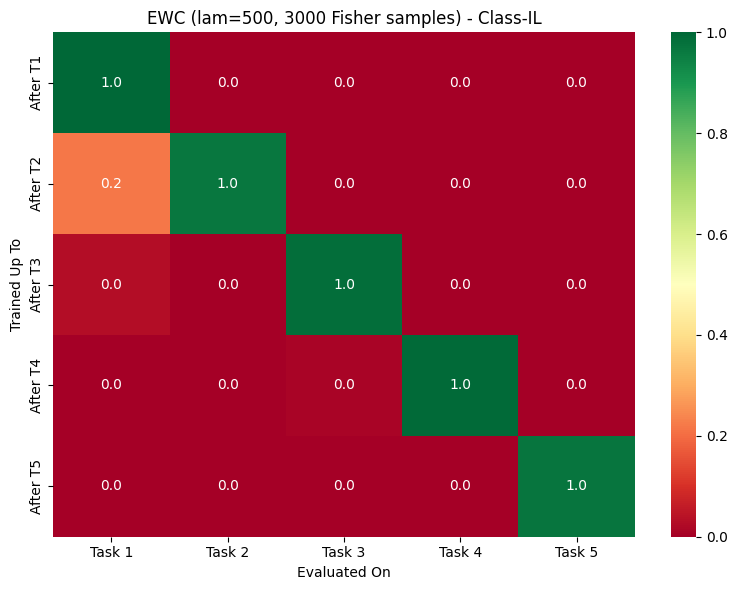

In [10]:
print("Running EWC (lam=500, fisher=3000)...")
ewc_3000_matrix = run_ewc_experiment(tasks, lam=500, num_fisher_samples=2000)
plot_matrix(ewc_3000_matrix, "EWC (lam=500, 3000 Fisher samples) - Class-IL")

## 11. Experiment 5: EWC with Fisher Samples = 6000 (half task data)

Running EWC (lam=5000, fisher=3000) with batching...

Training Task 1 (lam=500, lr_ewc=0.001, fisher_samples=3000)
Epoch: 1 Loss: 0.212279
Epoch: 2 Loss: 0.029351
Epoch: 3 Loss: 0.018863
Epoch: 4 Loss: 0.014551
Epoch: 5 Loss: 0.012137
Epoch: 6 Loss: 0.010566
Epoch: 7 Loss: 0.009450
Epoch: 8 Loss: 0.008608
Epoch: 9 Loss: 0.007946
Epoch: 10 Loss: 0.007409
Epoch: 11 Loss: 0.006960
Epoch: 12 Loss: 0.006577
Epoch: 13 Loss: 0.006247
Epoch: 14 Loss: 0.005958
Epoch: 15 Loss: 0.005701
Epoch: 16 Loss: 0.005472
Epoch: 17 Loss: 0.005266
Epoch: 18 Loss: 0.005079
Epoch: 19 Loss: 0.004908
Epoch: 20 Loss: 0.004750
Epoch: 21 Loss: 0.004605
Epoch: 22 Loss: 0.004470
Epoch: 23 Loss: 0.004344
Epoch: 24 Loss: 0.004226
Epoch: 25 Loss: 0.004115

After Task 1:
  Task 1: 99.95%
  Task 2: 0.00%
  Task 3: 0.00%
  Task 4: 0.00%
  Task 5: 0.00%

Training Task 2 (lam=500, lr_ewc=0.001, fisher_samples=3000)
Epoch: 1 Loss: 2.958621
Epoch: 2 Loss: 0.526725
Epoch: 3 Loss: 0.398059
Epoch: 4 Loss: 0.333431
Epoch: 5 Loss: 

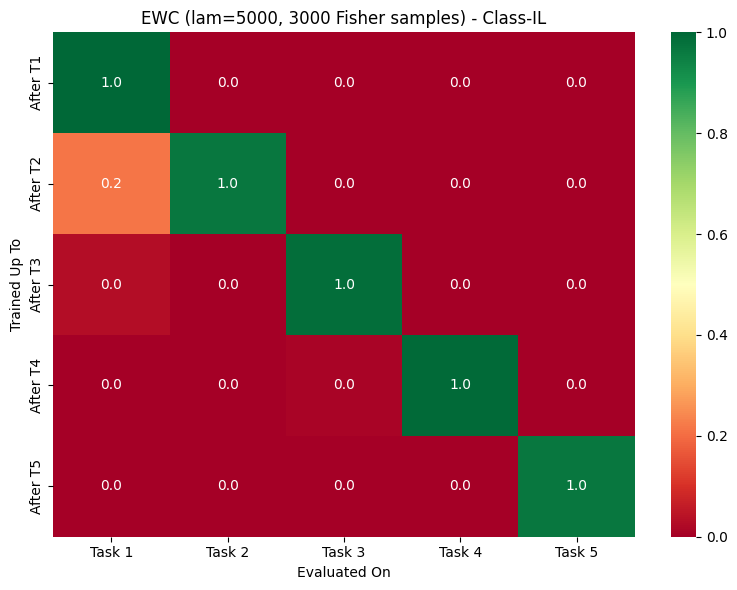

In [11]:
print("Running EWC (lam=5000, fisher=3000) with batching...")
ewc_6000_matrix = run_ewc_experiment(tasks, lam=500, num_fisher_samples=3000)
plot_matrix(ewc_6000_matrix, "EWC (lam=5000, 3000 Fisher samples) - Class-IL")

## 12. Experiment 6: EWC with Higher Lambda + More Samples

Running EWC (lam=10000, fisher=3000)...

Training Task 1 (lam=10000, lr_ewc=0.001, fisher_samples=3000)
Epoch: 1 Loss: 0.212279
Epoch: 2 Loss: 0.029351
Epoch: 3 Loss: 0.018863
Epoch: 4 Loss: 0.014551
Epoch: 5 Loss: 0.012137
Epoch: 6 Loss: 0.010566
Epoch: 7 Loss: 0.009450
Epoch: 8 Loss: 0.008608
Epoch: 9 Loss: 0.007946
Epoch: 10 Loss: 0.007409
Epoch: 11 Loss: 0.006960
Epoch: 12 Loss: 0.006577
Epoch: 13 Loss: 0.006247
Epoch: 14 Loss: 0.005958
Epoch: 15 Loss: 0.005701
Epoch: 16 Loss: 0.005472
Epoch: 17 Loss: 0.005266
Epoch: 18 Loss: 0.005079
Epoch: 19 Loss: 0.004908
Epoch: 20 Loss: 0.004750
Epoch: 21 Loss: 0.004605
Epoch: 22 Loss: 0.004470
Epoch: 23 Loss: 0.004344
Epoch: 24 Loss: 0.004226
Epoch: 25 Loss: 0.004115

After Task 1:
  Task 1: 99.95%
  Task 2: 0.00%
  Task 3: 0.00%
  Task 4: 0.00%
  Task 5: 0.00%

Training Task 2 (lam=10000, lr_ewc=0.001, fisher_samples=3000)
Epoch: 1 Loss: 3.204428
Epoch: 2 Loss: 0.664845
Epoch: 3 Loss: 0.465007
Epoch: 4 Loss: 0.373878
Epoch: 5 Loss: 0.320368


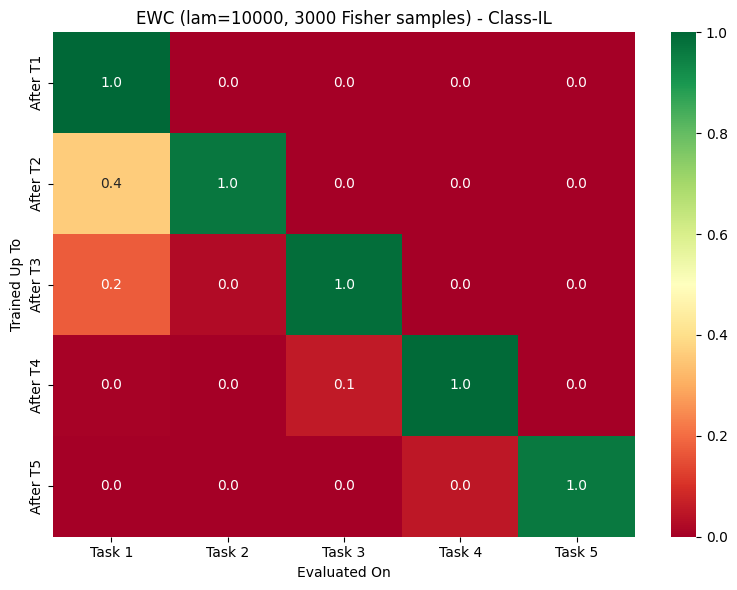

In [12]:
print("Running EWC (lam=10000, fisher=3000)...")
ewc_high_matrix = run_ewc_experiment(tasks, lam=10000, num_fisher_samples=4000)
plot_matrix(ewc_high_matrix, "EWC (lam=10000, 3000 Fisher samples) - Class-IL")

## 12. Experiment 7: EWC with Higher Lambda + More Samples

## 13. Results Comparison

In [13]:
def final_avg_accuracy(matrix):
    return np.mean(matrix[-1]) * 100

def task1_retention(matrix):
    return matrix[-1][0] * 100

print("=" * 70)
print("RESULTS COMPARISON")
print("=" * 70)
print(f"{'Method':<45} {'Avg Acc':>10} {'T1 Retain':>10}")
print("-" * 70)

results = [
    ("Naive (no EWC)", naive_matrix),
    ("EWC (lam=5000, fisher=200)", ewc_200_matrix),
    ("EWC (lam=5000, fisher=1000)", ewc_1000_matrix),
    ("EWC (lam=5000, fisher=3000)", ewc_3000_matrix),
    ("EWC (lam=5000, fisher=6000)", ewc_6000_matrix),
    ("EWC (lam=10000, fisher=3000)", ewc_high_matrix),
]

for name, matrix in results:
    avg = final_avg_accuracy(matrix)
    t1 = task1_retention(matrix)
    print(f"{name:<45} {avg:>9.2f}% {t1:>9.2f}%")

print("\nFinal accuracy row (after Task 5) for each method:")
print("-" * 70)
for name, matrix in results:
    row = matrix[-1]
    row_str = "  ".join([f"T{i+1}:{v*100:5.1f}%" for i, v in enumerate(row)])
    print(f"{name:<45} {row_str}")

RESULTS COMPARISON
Method                                           Avg Acc  T1 Retain
----------------------------------------------------------------------
Naive (no EWC)                                    19.66%      0.00%
EWC (lam=5000, fisher=200)                        19.90%      0.00%
EWC (lam=5000, fisher=1000)                       19.45%      0.00%
EWC (lam=5000, fisher=3000)                       19.41%      0.00%
EWC (lam=5000, fisher=6000)                       19.40%      0.00%
EWC (lam=10000, fisher=3000)                      20.26%      0.00%

Final accuracy row (after Task 5) for each method:
----------------------------------------------------------------------
Naive (no EWC)                                T1:  0.0%  T2:  0.0%  T3:  0.0%  T4:  0.0%  T5: 98.3%
EWC (lam=5000, fisher=200)                    T1:  0.0%  T2:  0.0%  T3:  0.0%  T4:  2.8%  T5: 96.7%
EWC (lam=5000, fisher=1000)                   T1:  0.0%  T2:  0.0%  T3:  0.0%  T4:  0.4%  T5: 96.8%
EWC (lam=50